# Interpreting the ESO spectrum object-type output

This notebook reads the SQLite database produced by `eso-object-types run`. It explains how ESO spectra, catalog objects, object types, and positional links fit together.

Important scientific interpretation:

- A link means that a catalog object lies inside the cone used for an ESO spectrum.
- It does **not** mean that the object was detected in the spectrum or was the intended target.
- The prototype radius is `max(s_fov / 2, 1 arcsec)`. For production, the meaning of `s_fov` should be validated by instrument and replaced by `s_region` where appropriate.
- SIMBAD and NED objects remain separate because the two services do not share a universal object identifier.
- Only the primary SIMBAD type and preferred NED physical type are stored.

In [1]:
from pathlib import Path
import json
import sqlite3

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", 100)

def find_repository_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not find the repository root from the current directory")

REPO_ROOT = find_repository_root(Path.cwd().resolve())
DB_PATH = REPO_ROOT / "output" / "eso_object_types.sqlite"
if not DB_PATH.exists():
    raise FileNotFoundError(
        f"Database not found at {DB_PATH}. Run `eso-object-types run` first."
    )

connection = sqlite3.connect(DB_PATH)
print(f"Database: {DB_PATH}")

Database: /Users/abarnes/Library/CloudStorage/Dropbox/GitHub/ESOArchive_objects/output/eso_object_types.sqlite


## 1. Select a pipeline run

The database can contain several runs. By default, the notebook selects the latest one. Change `RUN_ID` below if you want to inspect an older run.

In [2]:
runs = pd.read_sql_query(
    """
    SELECT run_id, started_at, finished_at, status, config_json, summary_json
    FROM pipeline_runs
    ORDER BY started_at DESC
    """,
    connection,
)
if runs.empty:
    raise RuntimeError("The database contains no pipeline runs")

display(runs[["run_id", "started_at", "finished_at", "status"]])
RUN_ID = runs.loc[0, "run_id"]
run_config = json.loads(runs.loc[0, "config_json"])
run_summary = json.loads(runs.loc[0, "summary_json"] or "{}")
print(f"Selected run: {RUN_ID}")
display(pd.Series(run_config, name="value").rename_axis("setting").to_frame())

,run_id,started_at,finished_at,status
0,20260723T193710Z-324ad2,2026-07-23T19:37:10.170248+00:00,2026-07-23T19:37:35.852417+00:00,completed


Selected run: 20260723T193710Z-324ad2


,value
setting,
eso_endpoint,https://archive.eso.org/tap_obs
limit,50
min_radius_arcsec,1.0
ned_batch_size,50
ned_endpoint,https://ned.ipac.caltech.edu/tap
output_dir,output
retries,5
simbad_batch_size,50000
simbad_endpoint,https://simbad.cds.unistra.fr/simbad/sim-tap


## 2. Understand the relational model

The central relationship is:

`pipeline_runs -> run_observations -> observations -> observation_objects -> catalog_objects -> object_types`

- `observations` contains one row for each ESO data product, keyed by `eso_dp_id`.
- `run_observations` says which ESO rows belong to this run.
- `catalog_objects` stores each SIMBAD or NED object once, keyed by `(catalog, catalog_object_id)`.
- `observation_objects` is the many-to-many link table. One spectrum can contain several objects, and one object can fall within several spectra.
- `object_types` avoids repeating type labels and descriptions for every object.
- `service_calls` records batching, attempts, timing, completion, and failures.

In [3]:
service_calls = pd.read_sql_query(
    """
    SELECT service, batch_number, input_count, attempt_count, result_count,
           status, ROUND(elapsed_seconds, 3) AS elapsed_seconds,
           error_type, error_message
    FROM service_calls
    WHERE run_id = ?
    ORDER BY service, batch_number
    """,
    connection,
    params=(RUN_ID,),
)
display(service_calls)

,service,batch_number,input_count,attempt_count,result_count,status,elapsed_seconds,error_type,error_message
0,eso,1,50,1,50,completed,0.703,None,None
1,ned,1,37,1,53,completed,2.884,None,None
2,simbad,1,37,1,41,completed,0.330,None,None


## 3. Inspect the ESO spectrum sample

`search_radius_arcsec` is the actual matching radius. `s_fov_arcsec` is the full characteristic field of view reported by ESO. The order-10 HEALPix value is a spatial partition key for future scaling, not a match criterion.

In [4]:
observations = pd.read_sql_query(
    """
    SELECT o.eso_dp_id, o.target_name, o.instrument_name,
           o.ra_deg, o.dec_deg,
           ROUND(o.s_fov_deg * 3600.0, 4) AS s_fov_arcsec,
           ROUND(o.search_radius_deg * 3600.0, 4) AS search_radius_arcsec,
           o.healpix_order10, o.s_region
    FROM observations AS o
    JOIN run_observations AS ro USING (eso_dp_id)
    WHERE ro.run_id = ?
    ORDER BY o.eso_dp_id
    """,
    connection,
    params=(RUN_ID,),
)
print(f"ESO spectra in run: {len(observations)}")
display(observations.head(10))

ESO spectra in run: 50


,eso_dp_id,target_name,instrument_name,ra_deg,dec_deg,s_fov_arcsec,search_radius_arcsec,healpix_order10,s_region
0,ADP.2014-01-20T10:01:42.390,OGLE-2013-SN-011,EFOSC,71.795500,-64.043472,1.0,1.0,8485379,POSITION J2000 71.7955 -64.043472
1,ADP.2014-01-20T10:01:42.403,LSQ13sj,EFOSC,199.574000,-2.861916,1.0,1.0,6614984,POSITION J2000 199.574 -2.861916
2,ADP.2014-01-20T10:01:42.423,LSQ12dyw,EFOSC,352.353666,-7.389083,1.0,1.0,4438580,POSITION J2000 352.353666 -7.389083
3,ADP.2014-01-20T10:01:42.430,LSQ12cda,EFOSC,207.509708,9.629805,1.5,1.0,6776171,POSITION J2000 207.509708 9.629805
4,ADP.2014-01-20T10:01:42.443,LSQ12ezn,EFOSC,54.439875,-37.265750,1.0,1.0,8839502,POSITION J2000 54.439875 -37.26575
5,ADP.2014-01-20T10:01:42.450,OGLE-2012-SN-006,EFOSC,53.394958,-74.394472,1.0,1.0,8442060,POSITION J2000 53.394958 -74.394472
6,ADP.2014-01-20T10:01:42.463,SN2012ht,EFOSC,163.344790,16.776360,1.0,1.0,7243402,POSITION J2000 163.34479 16.77636
7,ADP.2014-01-20T10:01:42.470,SN2012ca,EFOSC,280.280210,-41.794000,1.0,1.0,12227995,POSITION J2000 280.28021 -41.794
8,ADP.2014-01-20T10:01:42.477,SN2012ec,SOFI,41.499500,-7.574170,1.0,1.0,9417996,POSITION J2000 41.49950000000001 -7.57417
9,ADP.2014-01-20T10:01:42.483,SN2013K,EFOSC,264.881416,-85.310583,1.0,1.0,10490914,POSITION J2000 264.881416 -85.310583


## 4. Inspect catalog matches

The catalog ID is the deduplication key within its provider: SIMBAD `oid` or NED `objid`. `separation_arcsec` is calculated from the catalog coordinate and the ESO spectrum coordinate.

In [5]:
matches = pd.read_sql_query(
    """
    SELECT oo.eso_dp_id, o.target_name AS eso_target_name,
           oo.catalog, oo.catalog_object_id,
           co.preferred_name AS catalog_name,
           co.primary_type_code, ot.type_label, ot.type_description,
           ROUND(oo.separation_arcsec, 5) AS separation_arcsec,
           ROUND(o.search_radius_deg * 3600.0, 5) AS search_radius_arcsec
    FROM observation_objects AS oo
    JOIN run_observations AS ro USING (eso_dp_id)
    JOIN observations AS o USING (eso_dp_id)
    JOIN catalog_objects AS co
      ON co.catalog = oo.catalog
     AND co.catalog_object_id = oo.catalog_object_id
    LEFT JOIN object_types AS ot
      ON ot.catalog = co.catalog
     AND ot.type_code = co.primary_type_code
    WHERE ro.run_id = ?
    ORDER BY oo.eso_dp_id, oo.catalog, oo.separation_arcsec
    """,
    connection,
    params=(RUN_ID,),
)
print(f"Object-to-spectrum links: {len(matches)}")
print(f"Unique catalog objects: {matches[["catalog", "catalog_object_id"]].drop_duplicates().shape[0]}")
display(matches.head(20))

Object-to-spectrum links: 94
Unique catalog objects: 68


,eso_dp_id,eso_target_name,catalog,catalog_object_id,catalog_name,primary_type_code,type_label,type_description,separation_arcsec,search_radius_arcsec
0,ADP.2014-01-20T10:01:42.390,OGLE-2013-SN-011,simbad,9590178,OGLE 2013-SN-11,SN*,Supernova,SuperNova,0.00080,1.0
1,ADP.2014-01-20T10:01:42.403,LSQ13sj,ned,228381126,LSQ13sj,V*,V*,NaN,0.00240,1.0
2,ADP.2014-01-20T10:01:42.403,LSQ13sj,simbad,9623549,LSQ 13sj,SN?,Supernova_Candidate,SuperNova Candidate,0.00240,1.0
3,ADP.2014-01-20T10:01:42.423,LSQ12dyw,ned,196622746,WISEA J232924.87-072321.2,NaN,NaN,NaN,0.53257,1.0
4,ADP.2014-01-20T10:01:42.423,LSQ12dyw,ned,228381531,LSQ12dyw,SN,SN,NaN,0.93896,1.0
5,ADP.2014-01-20T10:01:42.423,LSQ12dyw,simbad,9383604,SDSS J232924.87-072320.5,G,Galaxy,Galaxy,0.10482,1.0
6,ADP.2014-01-20T10:01:42.423,LSQ12dyw,simbad,9382948,LSQ 12dyw,SN*,Supernova,SuperNova,0.93896,1.0
7,ADP.2014-01-20T10:01:42.430,LSQ12cda,ned,228381169,LSQ12cda,SN,SN,NaN,0.00232,1.0
8,ADP.2014-01-20T10:01:42.430,LSQ12cda,simbad,9338601,LSQ 12cda,SN*,Supernova,SuperNova,0.00232,1.0
9,ADP.2014-01-20T10:01:42.443,LSQ12ezn,ned,228380594,LSQ12ezn,SN,SN,NaN,0.10000,1.0


## 5. Which object types occur most often?

These counts are link counts, not unique-object counts. An object appearing in several ESO spectra contributes one link to each spectrum.

,catalog,type_code,type_label,link_count,unique_objects,spectra
0,ned,SN,SN,32,24,32
1,simbad,SN*,Supernova,32,23,32
2,ned,G,G,9,6,9
3,ned,UNKNOWN,Unknown,6,4,6
4,ned,V*,V*,3,2,3
5,ned,GGroup,GGroup,2,1,2
6,simbad,GiG,GtowardsGroup,2,1,2
7,simbad,s*b,BlueSG,2,1,2
8,ned,*,*,1,1,1
9,simbad,*,Star,1,1,1


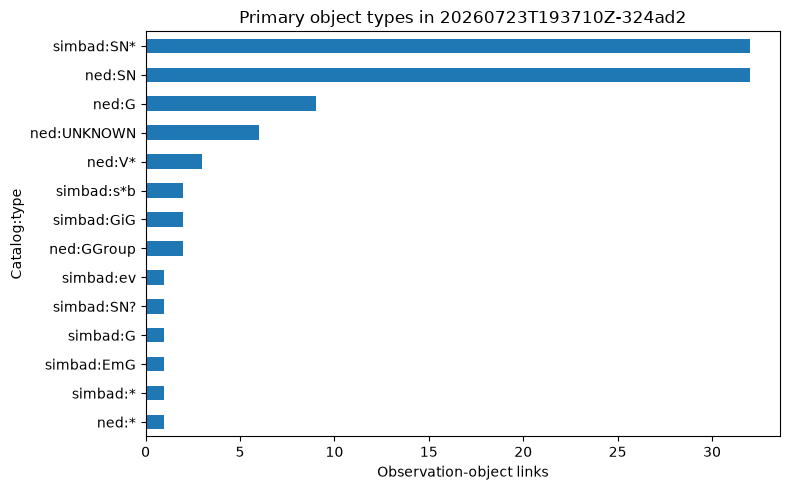

In [6]:
type_counts = pd.read_sql_query(
    """
    SELECT oo.catalog,
           COALESCE(co.primary_type_code, 'UNKNOWN') AS type_code,
           COALESCE(ot.type_label, co.primary_type_code, 'Unknown') AS type_label,
           COUNT(*) AS link_count,
           COUNT(DISTINCT oo.catalog_object_id) AS unique_objects,
           COUNT(DISTINCT oo.eso_dp_id) AS spectra
    FROM observation_objects AS oo
    JOIN run_observations AS ro USING (eso_dp_id)
    JOIN catalog_objects AS co
      ON co.catalog = oo.catalog
     AND co.catalog_object_id = oo.catalog_object_id
    LEFT JOIN object_types AS ot
      ON ot.catalog = co.catalog
     AND ot.type_code = co.primary_type_code
    WHERE ro.run_id = ?
    GROUP BY oo.catalog, COALESCE(co.primary_type_code, 'UNKNOWN')
    ORDER BY link_count DESC, oo.catalog, type_code
    """,
    connection,
    params=(RUN_ID,),
)
display(type_counts)

plot_data = type_counts.head(20).copy()
plot_data["display_type"] = plot_data["catalog"] + ":" + plot_data["type_code"]
ax = plot_data.sort_values("link_count").plot.barh(
    x="display_type", y="link_count", legend=False, figsize=(8, 5)
)
ax.set_xlabel("Observation-object links")
ax.set_ylabel("Catalog:type")
ax.set_title(f"Primary object types in {RUN_ID}")
plt.tight_layout()

## 6. Prototype an archive query by object type

Change `CATALOG` and `TYPE_CODE` to test the archive-style lookup. Use the previous table to find valid codes. Keeping the catalog in the filter is important because NED and SIMBAD type vocabularies differ.

In [7]:
CATALOG = "simbad"
TYPE_CODE = "SN*"

spectra_by_type = pd.read_sql_query(
    """
    SELECT DISTINCT o.eso_dp_id, o.target_name, o.instrument_name,
           o.ra_deg, o.dec_deg,
           co.preferred_name AS matched_object,
           co.primary_type_code,
           ROUND(oo.separation_arcsec, 5) AS separation_arcsec
    FROM observations AS o
    JOIN run_observations AS ro USING (eso_dp_id)
    JOIN observation_objects AS oo USING (eso_dp_id)
    JOIN catalog_objects AS co
      ON co.catalog = oo.catalog
     AND co.catalog_object_id = oo.catalog_object_id
    WHERE ro.run_id = ?
      AND co.catalog = ?
      AND co.primary_type_code = ?
    ORDER BY o.eso_dp_id, oo.separation_arcsec
    """,
    connection,
    params=(RUN_ID, CATALOG, TYPE_CODE),
)
print(f"Spectra containing {CATALOG}:{TYPE_CODE}: {spectra_by_type['eso_dp_id'].nunique()}")
display(spectra_by_type)

Spectra containing simbad:SN*: 32


,eso_dp_id,target_name,instrument_name,ra_deg,dec_deg,matched_object,primary_type_code,separation_arcsec
0,ADP.2014-01-20T10:01:42.390,OGLE-2013-SN-011,EFOSC,71.795500,-64.043472,OGLE 2013-SN-11,SN*,0.00080
1,ADP.2014-01-20T10:01:42.423,LSQ12dyw,EFOSC,352.353666,-7.389083,LSQ 12dyw,SN*,0.93896
2,ADP.2014-01-20T10:01:42.430,LSQ12cda,EFOSC,207.509708,9.629805,LSQ 12cda,SN*,0.00232
3,ADP.2014-01-20T10:01:42.450,OGLE-2012-SN-006,EFOSC,53.394958,-74.394472,OGLE 2012-SN-6,SN*,0.00086
4,ADP.2014-01-20T10:01:42.463,SN2012ht,EFOSC,163.344790,16.776360,SN 2012ht,SN*,0.73801
5,ADP.2014-01-20T10:01:42.470,SN2012ca,EFOSC,280.280210,-41.794000,SN 2012ca,SN*,0.00447
6,ADP.2014-01-20T10:01:42.483,SN2013K,EFOSC,264.881416,-85.310583,SN 2013K,SN*,0.00122
7,ADP.2014-01-20T10:01:42.490,LSQ12dwl,EFOSC,333.173125,0.511972,LSQ 12dwl,SN*,0.29999
8,ADP.2014-01-20T10:01:42.510,LSQ12bxu,EFOSC,216.852291,-20.907000,LSQ 12bxu,SN*,0.00224
9,ADP.2014-01-20T10:01:42.517,LSQ13fn,EFOSC,177.822041,-29.611444,LSQ 13fn,SN*,0.09842


## 7. A human-readable object list for each spectrum

This is close to what an archive results page could display. The relational tables remain preferable for storage because this combined string is only a presentation.

In [8]:
objects_per_spectrum = pd.read_sql_query(
    """
    SELECT o.eso_dp_id, o.target_name,
           COUNT(oo.catalog_object_id) AS object_links,
           GROUP_CONCAT(
               oo.catalog || ':' || COALESCE(co.preferred_name, co.catalog_object_id)
               || ' [' || COALESCE(co.primary_type_code, 'UNKNOWN') || ']',
               '; '
           ) AS objects_in_cone
    FROM observations AS o
    JOIN run_observations AS ro USING (eso_dp_id)
    LEFT JOIN observation_objects AS oo USING (eso_dp_id)
    LEFT JOIN catalog_objects AS co
      ON co.catalog = oo.catalog
     AND co.catalog_object_id = oo.catalog_object_id
    WHERE ro.run_id = ?
    GROUP BY o.eso_dp_id, o.target_name
    ORDER BY object_links DESC, o.eso_dp_id
    """,
    connection,
    params=(RUN_ID,),
)
display(objects_per_spectrum)

,eso_dp_id,target_name,object_links,objects_in_cone
0,ADP.2014-01-20T10:01:42.483,SN2013K,5,ned:PGC1 0060648 GROUP [GGroup]; ned:SN 2013K [SN]; ned:ESO 009- G 010 [G]; simbad:ESO 9-10 [GiG]; simbad:SN 2013K...
1,ADP.2014-01-20T10:01:42.903,SN2013K,5,ned:PGC1 0060648 GROUP [GGroup]; ned:SN 2013K [SN]; ned:ESO 009- G 010 [G]; simbad:ESO 9-10 [GiG]; simbad:SN 2013K...
2,ADP.2014-01-20T10:01:42.423,LSQ12dyw,4,ned:WISEA J232924.87-072321.2 [UNKNOWN]; ned:LSQ12dyw [SN]; simbad:LSQ 12dyw [SN*]; simbad:SDSS J232924.87-072320.5 [G]
3,ADP.2014-01-20T10:01:42.490,LSQ12dwl,4,ned:SDSS J221241.53+003042.7:SN [SN]; ned:WISEA J221241.50+003042.9 [G]; simbad:LSQ 12dwl [SN*]; simbad:2SLAQ J22124...
4,ADP.2014-01-20T10:01:42.450,OGLE-2012-SN-006,3,ned:OGLE-2012-SN-006 [SN]; ned:OGLE-2012-SN-006 HOST [G]; simbad:OGLE 2012-SN-6 [SN*]
5,ADP.2014-01-20T10:01:42.510,LSQ12bxu,3,ned:LSQ12bxu [SN]; ned:WISEA J142724.55-205425.0 [UNKNOWN]; simbad:LSQ 12bxu [SN*]
6,ADP.2014-01-20T10:01:42.683,SSS130404-102043-062657,3,ned:SN 2013bg [SN]; ned:CRTS J102042.87-062656.8 [G]; simbad:SN 2013bg [SN*]
7,ADP.2014-01-20T10:01:42.803,SN2013ao,3,ned:SN 2013ao [SN]; ned:CRTS J114444.74-203141.1 [G]; simbad:SN 2013ao [SN*]
8,ADP.2014-01-20T10:01:42.910,LSQ12bnt,3,ned:LSQ12bnt [SN]; ned:SDSS J125132.27+040125.1 [G]; simbad:LSQ 12bnt [SN*]
9,ADP.2014-01-20T10:01:42.950,OGLE-2012-SN-006,3,ned:OGLE-2012-SN-006 [SN]; ned:OGLE-2012-SN-006 HOST [G]; simbad:OGLE 2012-SN-6 [SN*]


## 8. Spectra with no catalog match

A zero-match spectrum is a valid result. It may reflect a small footprint, incomplete catalog coverage, coordinate differences, or an object outside NED's extragalactic focus.

In [9]:
unmatched = pd.read_sql_query(
    """
    SELECT o.eso_dp_id, o.target_name, o.instrument_name,
           o.ra_deg, o.dec_deg,
           ROUND(o.search_radius_deg * 3600.0, 4) AS search_radius_arcsec
    FROM observations AS o
    JOIN run_observations AS ro USING (eso_dp_id)
    LEFT JOIN observation_objects AS oo USING (eso_dp_id)
    WHERE ro.run_id = ?
      AND oo.eso_dp_id IS NULL
    ORDER BY o.eso_dp_id
    """,
    connection,
    params=(RUN_ID,),
)
print(f"Spectra with no SIMBAD or NED match: {len(unmatched)}")
display(unmatched)

Spectra with no SIMBAD or NED match: 9


,eso_dp_id,target_name,instrument_name,ra_deg,dec_deg,search_radius_arcsec
0,ADP.2014-01-20T10:01:42.597,LSQ12ezu,EFOSC,355.076500,-21.155888,1.0
1,ADP.2014-01-20T10:01:42.623,LSQ12dvl,EFOSC,27.333750,1.710944,1.0
2,ADP.2014-01-20T10:01:42.677,SN2012fr,SOFI,53.400416,-36.126111,1.0
3,ADP.2014-01-20T10:01:42.703,SN2012fr,SOFI,53.400416,-36.126111,1.0
4,ADP.2014-01-20T10:01:42.737,LSQ12flb,EFOSC,68.123333,-3.307277,1.0
5,ADP.2014-01-20T10:01:42.777,LSQ12hcm,EFOSC,55.531291,4.231611,1.0
6,ADP.2014-01-20T10:01:42.797,LSQ12hbo,EFOSC,164.064833,-20.858805,1.0
7,ADP.2014-01-20T10:01:42.850,LSQ12cbv,EFOSC,251.287108,-24.521880,1.0
8,ADP.2014-01-20T10:01:42.923,SN2012fr,SOFI,53.400416,-36.126111,1.0


## 9. Validate the stored links

All three values below should be zero. The database primary keys prevent duplicates, while the last check confirms that every link lies within the cone used for its ESO spectrum.

In [10]:
validation = pd.read_sql_query(
    """
    SELECT 'duplicate catalog object keys' AS check_name, COUNT(*) AS failures
    FROM (
        SELECT catalog, catalog_object_id
        FROM catalog_objects
        GROUP BY catalog, catalog_object_id
        HAVING COUNT(*) > 1
    )
    UNION ALL
    SELECT 'duplicate observation-object links', COUNT(*)
    FROM (
        SELECT eso_dp_id, catalog, catalog_object_id
        FROM observation_objects
        GROUP BY eso_dp_id, catalog, catalog_object_id
        HAVING COUNT(*) > 1
    )
    UNION ALL
    SELECT 'links outside search radius', COUNT(*)
    FROM observation_objects AS oo
    JOIN run_observations AS ro USING (eso_dp_id)
    JOIN observations AS o USING (eso_dp_id)
    WHERE ro.run_id = ?
      AND oo.separation_arcsec > o.search_radius_deg * 3600.0 + 1e-6
    """,
    connection,
    params=(RUN_ID,),
)
display(validation)
assert (validation["failures"] == 0).all(), "One or more database checks failed"

,check_name,failures
0,duplicate catalog object keys,0
1,duplicate observation-object links,0
2,links outside search radius,0


## 10. Read the scale estimate carefully

The estimate extrapolates the observed fraction of unique search positions to two million spectra. The SIMBAD number is a plausible batch-count estimate. The NED number demonstrates why the public cone-batch workflow must not simply be multiplied to production scale. A bulk NED snapshot or an explicitly approved, cached sky-tile workflow is required.

In [11]:
scale_metrics = {
    key: value for key, value in run_summary.items() if key.startswith("scale.")
}
display(pd.Series(scale_metrics, name="value").rename_axis("metric").to_frame())

connection.close()

,value
metric,
scale.ned_public_tap_bulk_ready,no
scale.projected_ned_batches_for_2m,29600
scale.projected_simbad_batches_for_2m,30
scale.projected_unique_positions_for_2m,1480000
